In [1]:
import numpy as np
import pandas as pd
import h5py

from SushiLife import *

In [2]:
f = h5py.File("../../../../data/stock_info.hdf5", "r")
array_stock, axis_stock = load_data(f, "stock", chunks=5, in_memory=False)
array_value, axis_value = load_data(f, "value", chunks=5, in_memory=False)

data_stock = DataAsset(array_stock, axis_stock, chunks=5)
data_value = DataAsset(array_value, axis_value, chunks=5)

# with pandas dataframe

In [3]:
%%time
updater = Updater(pd.Timestamp(2002, 6, 15), data_stock.dates)

# 거래소 생성
exchange_stock = Exchange()
exchange_stock.set_DataAsset(data_stock)

# 주식 계좌 생성
stock_account = StockAccount(exchange_stock, 출력=False)

# 거래 에이전트 생성 및 주식 계좌 등록
agent = Agent(1e8, 출력=False)
agent.set_account("stock", stock_account)

# 날짜가 변할시 업데이트 요청
updater.set_data(data_stock)
updater.set_data(data_value)

updater.set_exchange(exchange_stock)

updater.set_agent(agent)

updater.initialization()

# 백테스트
columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
           "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]

while updater._date != updater._list_date[-1]:
    fin_stat = data_value.get_info(updater._date, num=2,
                                   fields=columns)

    df = pd.DataFrame(fin_stat[-2], index=data_value.codes, columns=columns)
    df = df[~np.isnan(df["상장시가총액(원)"])]  # 상장종목 고려
    df = df.sort_values(by=['상장시가총액(원)']).iloc[:int(len(df.index) * 0.3)]  # 소형주

    # 종목선정
    df["PER"] = df["상장시가총액(원)"] / df["지배주주순이익(원)(직전4분기)"]
    df["PBR"] = df["상장시가총액(원)"] / df["지배주주지분(원)"]
    df["PCR"] = df["상장시가총액(원)"] / df["현금흐름(원)(직전4분기)"]
    df["PSR"] = df["상장시가총액(원)"] / df["매출액(원)(직전4분기)"]

    df = df[df["PER"] > 0]
    df = df[df["PBR"] > 0]
    df = df[df["PCR"] > 0]
    df = df[df["PSR"] > 0]

    df["Rank"] = (df["PER"].rank() + df["PBR"].rank() + df["PCR"].rank() + df["PSR"].rank()).rank()

    df = df[df["Rank"] < 51]

    # 매도
    매도종목 = agent.accounts["stock"].keys()
    매수종목 = np.sort(df.index)
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)

    i = 0
    for 종목코드 in 매도종목:
        매도수량 = agent.accounts["stock"][종목코드]["보유수량"]
        agent.sell("stock", 종목코드, 현재가[i], 매도수량, 주문종류="조건부지정가")
        i += 1

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1)
    i = 0
    for 종목코드 in 매수종목:
        if not np.isnan(현재가[i]):
            매수수량 = int(agent.total_balance / 50 / 현재가[i])
            agent.buy("stock", 종목코드, 현재가[i], 매수수량, 주문종류="조건부지정가")
        i += 1

    for i in range(21):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

Wall time: 23.1 s


In [4]:
레포트1 = pd.DataFrame(agent.report)
레포트1

,수익률(%),누적수익률(%),총자산(원),현금자산,현물자산,CAGR(%),일평균수익률(%),MDD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,1.000000e+08,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2002-06-17
1,0.000000,0.000000,1.000000e+08,4.277220e+06,1.000000e+08,0.000000,0.000000,0.000000,0.000000,2002-06-17
2,0.168540,0.168540,1.001685e+08,4.277220e+06,1.001685e+08,35.978499,0.084235,0.000000,0.168540,2002-06-18
3,-3.710237,-3.547950,9.645205e+07,4.277220e+06,9.645205e+07,-98.766248,-1.196919,-3.710237,0.168540,2002-06-19
4,-0.011716,-3.559250,9.644075e+07,4.277220e+06,9.644075e+07,-96.337498,-0.901942,-3.721518,0.168540,2002-06-20
5,0.304513,-3.265575,9.673442e+07,4.277220e+06,9.673442e+07,-91.140342,-0.661817,-3.721518,0.168540,2002-06-21
6,-0.943175,-4.177950,9.582205e+07,4.277220e+06,9.582205e+07,-85.732052,-0.532047,-4.339177,0.168540,2002-06-24
7,-0.394486,-4.555955,9.544404e+07,4.277220e+06,9.544404e+07,-84.909528,-0.516772,-4.716546,0.168540,2002-06-25
8,-5.788591,-10.080820,8.991918e+07,4.277220e+06,8.991918e+07,-97.931715,-1.056964,-10.232115,0.168540,2002-06-26
9,0.793179,-9.367600,9.063240e+07,4.277220e+06,9.063240e+07,-96.175381,-0.890182,-10.232115,0.168540,2002-06-27


# Pure numpy

dataframe을 사용하지 않고 numpy만 사용할 경우 3배까지 속도향상 가능

In [5]:
%%time
updater = Updater(pd.Timestamp(2002, 6, 15), data_stock.dates)

# 거래소 생성
exchange_stock = Exchange()
exchange_stock.set_DataAsset(data_stock)

# 주식 계좌 생성
stock_account = StockAccount(exchange_stock, 출력=False)

# 거래 에이전트 생성 및 주식 계좌 등록
agent = Agent(1e8, 출력=False)
agent.set_account("stock", stock_account)

# 날짜가 변할시 업데이트 요청
updater.set_data(data_stock)
updater.set_data(data_value)

updater.set_exchange(exchange_stock)

updater.set_agent(agent)

updater.initialization()

# 백테스트

columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
   "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]

while updater._date != updater._list_date[-1]:
    fin_stat = data_value.get_info(updater._date, num=2,
                             fields=columns)
    
    fin_stat = fin_stat[-2]
    상장시가총액 = fin_stat[:, 0]
    
    # 상장종목 고려
    상장종목 = ~np.isnan(상장시가총액)
    
    종목코드 = np.array(data_value.codes)[상장종목]
    상장시가총액 = 상장시가총액[상장종목]
    values = 상장시가총액.reshape(-1, 1) / fin_stat[상장종목, 1:]
    
    # 소형주
    시가총액순위 = 상장시가총액.argsort().argsort()
    시가총액조건 = 시가총액순위 < len(시가총액순위) * 0.3 # 상장종목 & 소형주
    
    values = values[시가총액조건, :]
    종목코드 = 종목코드[시가총액조건]
    
    # 양수
    cond_positive = (values > 0).all(axis=1)
    values = values[cond_positive, :]
    종목코드 = 종목코드[cond_positive]

    rank_each = values.argsort(axis=0).argsort(axis=0)
    sum_rank = np.sum(rank_each, axis=1)
    rank = sum_rank.argsort(axis=0).argsort(axis=0)

    cond_rank = rank < 50
    매수종목 = 종목코드[cond_rank]

    # 매도
    매도종목 = agent.accounts["stock"].keys()
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)
    
    i = 0
    for 종목코드 in 매도종목:
        매도수량 = agent.accounts["stock"][종목코드]["보유수량"]
        agent.sell("stock", 종목코드, 현재가[i], 매도수량)
        i += 1

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1)
    i = 0
    for 종목코드 in 매수종목:
        if not np.isnan(현재가[i]):
            매수수량 = int(agent.total_balance / 50 / 현재가[i])
            agent.buy("stock", 종목코드, 현재가[i], 매수수량, 주문종류="조건부지정가")
        i += 1

    for i in range(21):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

c:\users\wkwek\appdata\local\programs\python\python36\lib\site-packages\ipykernel_launcher.py:51: RuntimeWarning: invalid value encountered in greater
c:\users\wkwek\appdata\local\programs\python\python36\lib\site-packages\ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in true_divide


Wall time: 18.1 s


In [6]:
레포트2 = pd.DataFrame(agent.report)
레포트2

,수익률(%),누적수익률(%),총자산(원),현금자산,현물자산,CAGR(%),일평균수익률(%),MDD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,1.000000e+08,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2002-06-17
1,0.000000,0.000000,1.000000e+08,4.277220e+06,1.000000e+08,0.000000,0.000000,0.000000,0.000000,2002-06-17
2,0.168540,0.168540,1.001685e+08,4.277220e+06,1.001685e+08,35.978499,0.084235,0.000000,0.168540,2002-06-18
3,-3.710237,-3.547950,9.645205e+07,4.277220e+06,9.645205e+07,-98.766248,-1.196919,-3.710237,0.168540,2002-06-19
4,-0.011716,-3.559250,9.644075e+07,4.277220e+06,9.644075e+07,-96.337498,-0.901942,-3.721518,0.168540,2002-06-20
5,0.304513,-3.265575,9.673442e+07,4.277220e+06,9.673442e+07,-91.140342,-0.661817,-3.721518,0.168540,2002-06-21
6,-0.943175,-4.177950,9.582205e+07,4.277220e+06,9.582205e+07,-85.732052,-0.532047,-4.339177,0.168540,2002-06-24
7,-0.394486,-4.555955,9.544404e+07,4.277220e+06,9.544404e+07,-84.909528,-0.516772,-4.716546,0.168540,2002-06-25
8,-5.788591,-10.080820,8.991918e+07,4.277220e+06,8.991918e+07,-97.931715,-1.056964,-10.232115,0.168540,2002-06-26
9,0.793179,-9.367600,9.063240e+07,4.277220e+06,9.063240e+07,-96.175381,-0.890182,-10.232115,0.168540,2002-06-27


In [7]:
import matplotlib.pyplot as plt

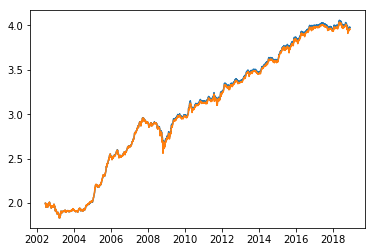

In [8]:
plt.plot(레포트1["날짜"], np.log10(레포트1["누적수익률(%)"] + 100))
plt.plot(레포트2["날짜"], np.log10(레포트2["누적수익률(%)"] + 100))

plt.show()